Dataset (**customer churn**) comes from Kaggle
https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset/data

## **Exploratory Data Analysis**

In [72]:
import pandas as pd
import numpy as np

First, we import the necessary libraries for data manipulation and numerical operations. `pandas` is used for working with dataframes, and `numpy` is used for numerical computations.

In [73]:
file = "customer_churn_dataset.csv"
data = pd.read_csv(file)
churn_col = data.pop('Churn')
data.insert(0, 'Churn', churn_col)

We load the dataset from a CSV file into a pandas DataFrame. For better readability, we move the target variable, 'Churn', to be the first column in the DataFrame.

In [74]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Churn              440832 non-null  float64
 1   CustomerID         440832 non-null  float64
 2   Age                440832 non-null  float64
 3   Gender             440832 non-null  str    
 4   Tenure             440832 non-null  float64
 5   Usage Frequency    440832 non-null  float64
 6   Support Calls      440832 non-null  float64
 7   Payment Delay      440832 non-null  float64
 8   Subscription Type  440832 non-null  str    
 9   Contract Length    440832 non-null  str    
 10  Total Spend        440832 non-null  float64
 11  Last Interaction   440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


The `.info()` output gives us a quick overview of the dataset's structure. We can see there are 440,833 entries and 12 columns in total. The columns are a mix of numerical (`float64`) and text (`str`) data types.

A key observation is that the `Non-Null Count` for all columns is 440,832, which is one less than the total number of entries (440,833). This indicates that there is at least one row in the dataset with missing values, which will need to be addressed.

In [75]:
data.describe().drop(columns=['CustomerID', 'Churn'])

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000


In [76]:
data.describe(include='str')

,Gender,Subscription Type,Contract Length
count,440832,440832,440832
unique,2,3,3
top,Male,Standard,Annual
freq,250252,149128,177198


#### **Missing data**

In [77]:
data.isna().sum()

Churn                1
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
dtype: int64

We check for missing values in each column. The output shows the total number of `NaN` values for every feature. We can see that every column has one lack of data.

In [78]:
data[data["Churn"].isna()]

,Churn,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
data = data.dropna()


Since there are only one row with missing data, we can afford to remove them from the dataset. We use `.dropna()` to delete all rows that contain at least one missing value.

In [80]:
data.isna().sum()

Churn                0
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
dtype: int64

After dropping the rows, we check for missing values again to confirm that our dataset is complete. 

### **Outliers**

In [81]:
def indices_of_outliers_iqr(df):
    outliers_indices = {}
    low_top_bound = {}
    numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.drop(['CustomerID', 'Churn'])
    for column in numeric_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_indx = np.where((df[column] < lower_bound) | (df[column] > upper_bound))
        outliers_indices[column] = outlier_indx[0]
        low_top_bound[column] = (lower_bound, upper_bound)
        
    return outliers_indices, low_top_bound

outliers_dict, bounds_dict = indices_of_outliers_iqr(data)

Outliers are data points that are very different from the rest of the data. We define a function to find outliers using the Interquartile Range (IQR) method. This function identifies data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR. It returns the indices of these outliers and the calculated bounds for each numerical column.

In [82]:
for key, value in bounds_dict.items():
    print(f"{key}, Lower bound: {value[0]}, Upper bound: {value[1]}")
print("\n")
for key, value in outliers_dict.items():
    print(f"{key}, amount of outliers: {len(value)}")


Age, Lower bound: 0.5, Upper bound: 76.5
Tenure, Lower bound: -29.0, Upper bound: 91.0
Usage Frequency, Lower bound: -12.0, Upper bound: 44.0
Support Calls, Lower bound: -6.5, Upper bound: 13.5
Payment Delay, Lower bound: -13.5, Upper bound: 38.5
Total Spend, Lower bound: -45.0, Upper bound: 1355.0
Last Interaction, Lower bound: -15.5, Upper bound: 44.5


Age, amount of outliers: 0
Tenure, amount of outliers: 0
Usage Frequency, amount of outliers: 0
Support Calls, amount of outliers: 0
Payment Delay, amount of outliers: 0
Total Spend, amount of outliers: 0
Last Interaction, amount of outliers: 0


The second part shows the amount of outliers found in each column. As you can see, the result is 0 for all features. This indicates that after cleaning the missing values, there are no extreme outliers in our dataset according to the 1.5 * IQR rule. This is a positive finding, as it suggests the data is clean and consistent, which is good for building a reliable machine learning model.

### **Data characteristics**

In [83]:
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.drop(['CustomerID', 'Churn'])
data[numeric_columns].describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000


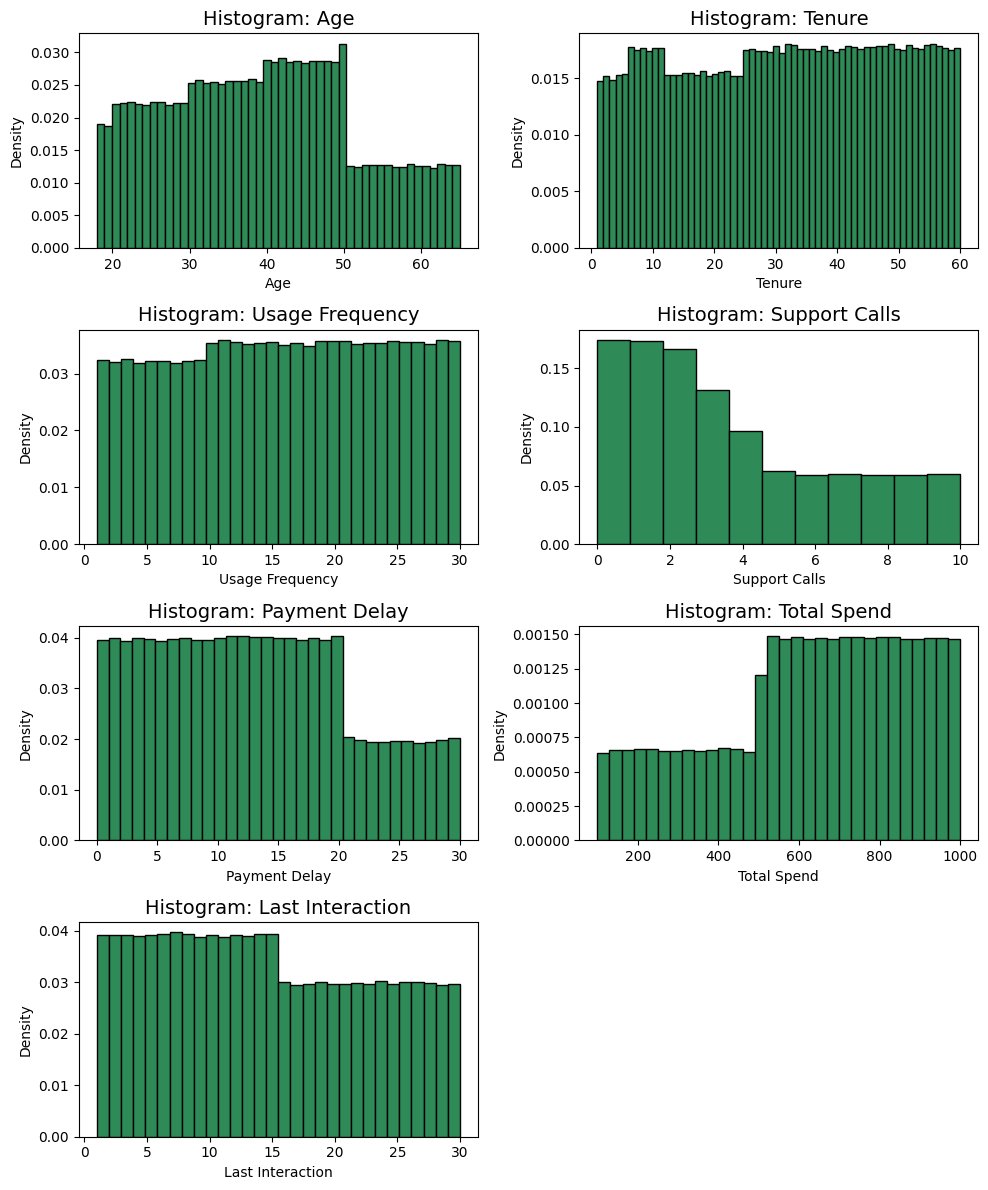

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguracja siatki wykresów (np. 4 wiersze, 2 kolumny)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    min_val = data[col].min()
    max_val = data[col].max()

    if max_val - min_val > 100:
        bins = 30
    else:
        bins = int(max_val - min_val + 1)

    axes[i].hist(data[col], bins=bins, color='seagreen', edgecolor='black', density=True)
    
    axes[i].set_title(f'Histogram: {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

if len(numeric_columns) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [85]:
import matplotlib.pyplot as plt

categorical_columns = data.select_dtypes(include=['str']).columns

for column in categorical_columns:
    counts = data[column].value_counts()
    percent = data[column].value_counts(normalize=True) * 100
    cat = pd.DataFrame({'counts': counts,
                        'Percentage': percent}).transpose()
    print(cat)
    print("\n")



Gender               Male         Female
counts      250252.000000  190580.000000
Percentage      56.768111      43.231889


Subscription Type      Standard       Premium          Basic
counts             149128.00000  148678.00000  143026.000000
Percentage             33.82876      33.72668      32.444559


Contract Length         Annual      Quarterly       Monthly
counts           177198.000000  176530.000000  87104.000000
Percentage           40.196265      40.044734     19.759001




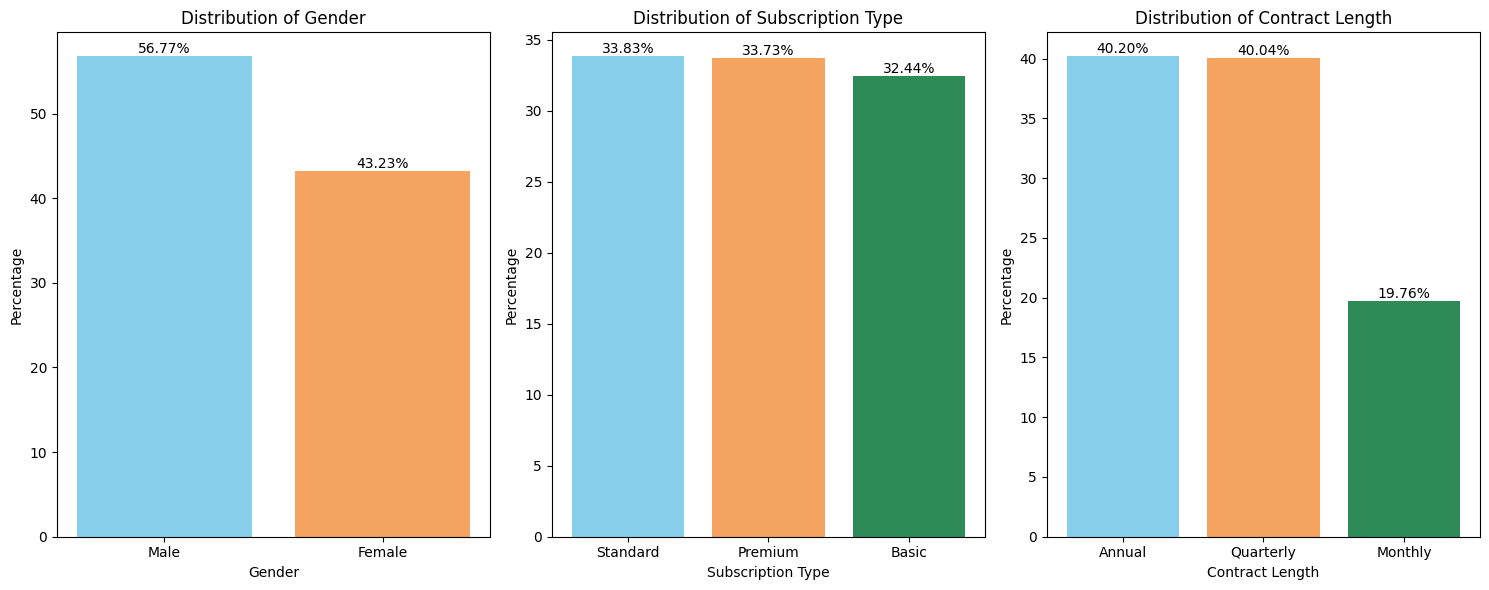

In [86]:
figs, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
for i, column in enumerate(categorical_columns):
    counts = data[column].value_counts(normalize=True) * 100
    bars = axes[i].bar(counts.index, counts.values, color=['skyblue', 'sandybrown', 'seagreen'])
    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Percentage')
    
    for bar in bars:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}%', va='bottom', ha='center')
        
plt.tight_layout()
plt.show()

Based on the plots, we can see a significant difference in gender distribution. On the other hand, the distribution of subscription types is almost uniform. Annual and quarterly contract lengths are nearly the same, while monthly contracts are the least common.

#### **Skewness**

In [87]:
data[numeric_columns].skew()

Age                 0.162016
Tenure             -0.061402
Usage Frequency    -0.043473
Support Calls       0.666809
Payment Delay       0.267407
Total Spend        -0.457174
Last Interaction    0.176774
dtype: float64

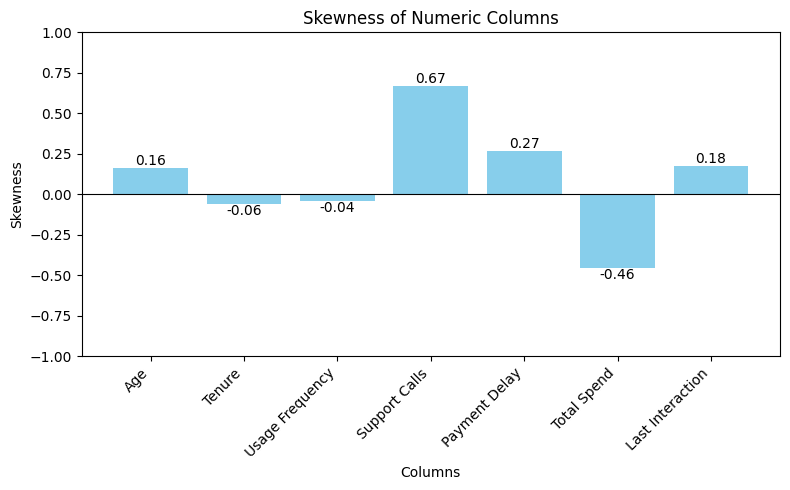

In [88]:
skewness = data[numeric_columns].skew()
plt.figure(figsize=(8, 5))
bars = plt.bar(skewness.index, skewness.values, color='skyblue')
plt.title('Skewness of Numeric Columns')
plt.xlabel('Columns')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >= 0 else 'top', ha='center')

plt.tight_layout()
plt.show()

**Age, Last Interaction, Payment Delay, Total Spend**: These variables fall within the -0.5 to 0.5 range, showing only slight skewness. Total Spend (-0.46) is leaning towards a left-skewed distribution, suggesting a slight concentration of higher-spending customers.

**Support Calls**: With a value of 0.67, this is the most skewed variable; the positive tail indicates a subset of customers who make significantly more support calls than the average customer.

#### **Kurtosis**

In [89]:
data[numeric_columns].kurtosis()

Age                -0.864853
Tenure             -1.192523
Usage Frequency    -1.175815
Support Calls      -0.745912
Payment Delay      -0.895678
Total Spend        -0.751489
Last Interaction   -1.153760
dtype: float64

Kurtosis provides insight into the risk of extreme values. A normal distribution has a kurtosis of 0. A positive kurtosis indicates heavy tails (more outliers), while a negative kurtosis indicates light tails (fewer outliers). We calculate the kurtosis for our numerical features.

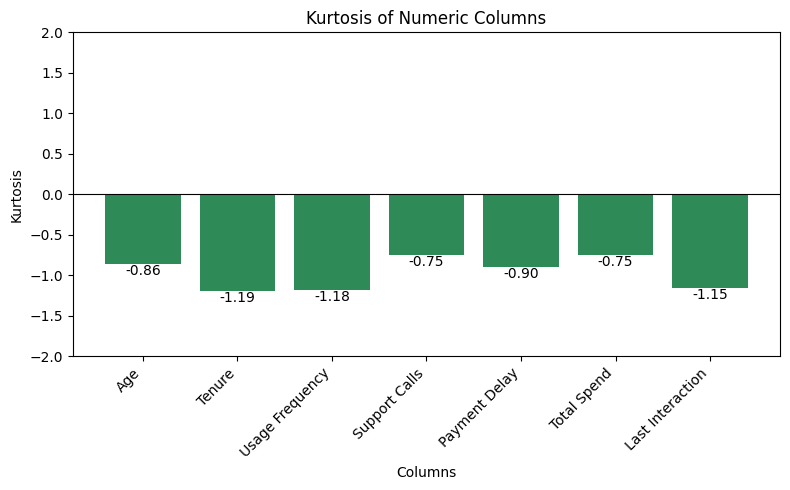

In [90]:
kurtosis = data[numeric_columns].kurtosis()
plt.figure(figsize=(8, 5))
bars = plt.bar(kurtosis.index, kurtosis.values, color='seagreen')
plt.title('Kurtosis of Numeric Columns')
plt.xlabel('Columns')
plt.ylabel('Kurtosis')
plt.xticks(rotation=45, ha='right')
plt.ylim(-2, 2)
plt.axhline(0, color='black', linewidth=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >= 0 else 'top', ha='center')

plt.tight_layout()
plt.show()

All numeric variables have negative kurtosis, indicating platykurtic distributions with flatter peaks and thinner tails, which suggests that the data points are more spread out and less prone to extreme outliers than a normal distribution.

#### **Data transformation**

In [91]:
from sklearn.preprocessing import OrdinalEncoder
untransformed_data = data.copy()
data = pd.get_dummies(data, columns=['Gender'])
oe = OrdinalEncoder(categories=[['Basic', 'Standard', 'Premium'],
                                ['Monthly', 'Quarterly', 'Annual']])
data[['Subscription Type', 'Contract Length']] = oe.fit_transform(
    data[['Subscription Type', 'Contract Length']])

Machine learning models require all input features to be numeric. We need to convert our categorical features into a numerical format.
- **One-Hot Encoding**: For the 'Gender' column, we use `pd.get_dummies`. This creates new columns ('Gender_Female', 'Gender_Male') with binary (0 or 1) values. This is suitable for nominal categories where there is no order.
- **Ordinal Encoding**: For 'Subscription Type' and 'Contract Length', there is a clear order (e.g., 'Basic' < 'Standard' < 'Premium'). We use `OrdinalEncoder` to convert these categories into numerical values (0, 1, 2) that respect this order.

#### **Correlation**

In [92]:
data.corr()['Churn'].drop('CustomerID').sort_values()

Total Spend         -0.429355
Contract Length     -0.346666
Gender_Male         -0.175395
Tenure              -0.051919
Usage Frequency     -0.046101
Subscription Type   -0.018251
Last Interaction     0.149616
Gender_Female        0.175395
Age                  0.218394
Payment Delay        0.312129
Support Calls        0.574267
Churn                1.000000
Name: Churn, dtype: float64

Here, we calculate the correlation between each feature and the 'Churn' variable. **Positive correlation** means that as the feature value increases, the likelihood of churn also increases. **Negative correlation** means that as the feature value increases, the likelihood of churn decreases.

`Total Spend` has the strongest negative correlation, suggesting that customers with higher spendings are less likely to churn. `Support Calls` has the highest positive correlation, this indicates that clients with more support calls are more likely to churn.

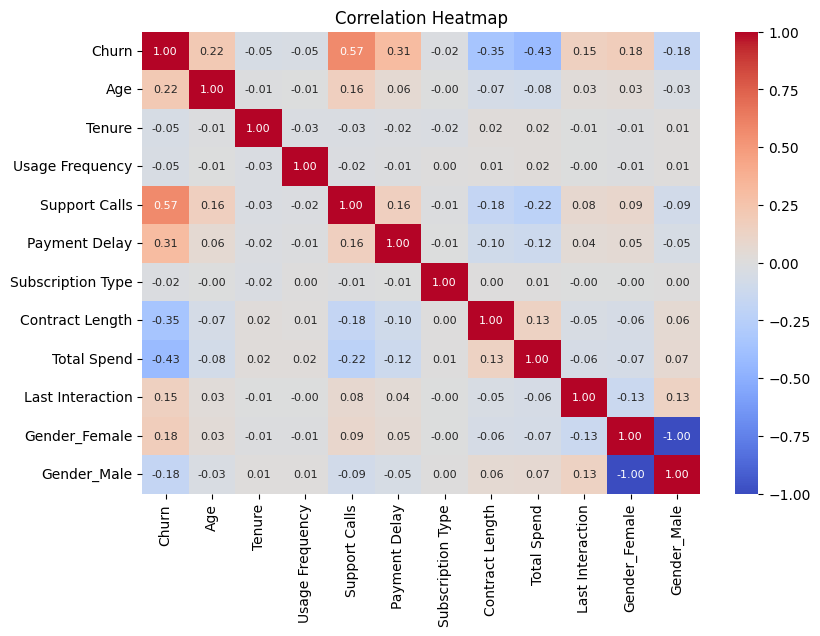

In [93]:
import seaborn as sns

correlation_matrix = data.drop(columns=[col for col in data.columns if data[col].dtype == 'object'] + ['CustomerID']).corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title('Correlation Heatmap')
plt.show()

#### **Bivariate Analysis**

In [94]:
untransformed_data.groupby('Churn')[['Support Calls', 'Total Spend']].mean()

,Support Calls,Total Spend
Churn,,
0.0,1.586418,749.953111
1.0,5.144861,541.285528


Grouping by Churn we are able to see significant difference beetwen the mean values of Support Calls and Total Spend.

Text(0.5, 1.0, 'Histogram of Support Calls by Churn')

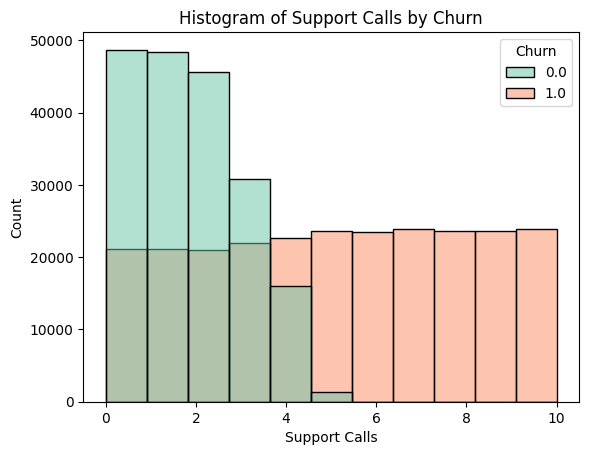

In [95]:
sns.histplot(data=untransformed_data, x='Support Calls', hue='Churn', bins=11, palette='Set2')
plt.title('Histogram of Support Calls by Churn', fontsize=12)

Retained customers rarely make more than five support calls.

Text(0.5, 1.0, 'Distribution of Total Spend by Churn')

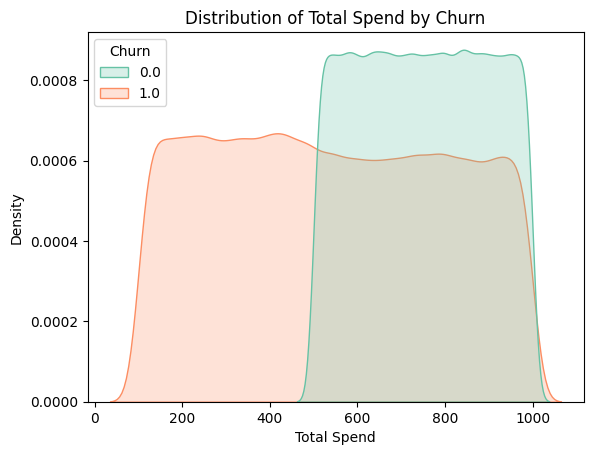

In [96]:
sns.kdeplot(data=untransformed_data, x='Total Spend', hue='Churn', palette='Set2', fill=True)
plt.title('Distribution of Total Spend by Churn', fontsize=12)

Retained customers are concentrated entirely in the 500 to 1000 bracket, while churned customers are spread across the entire spending range.

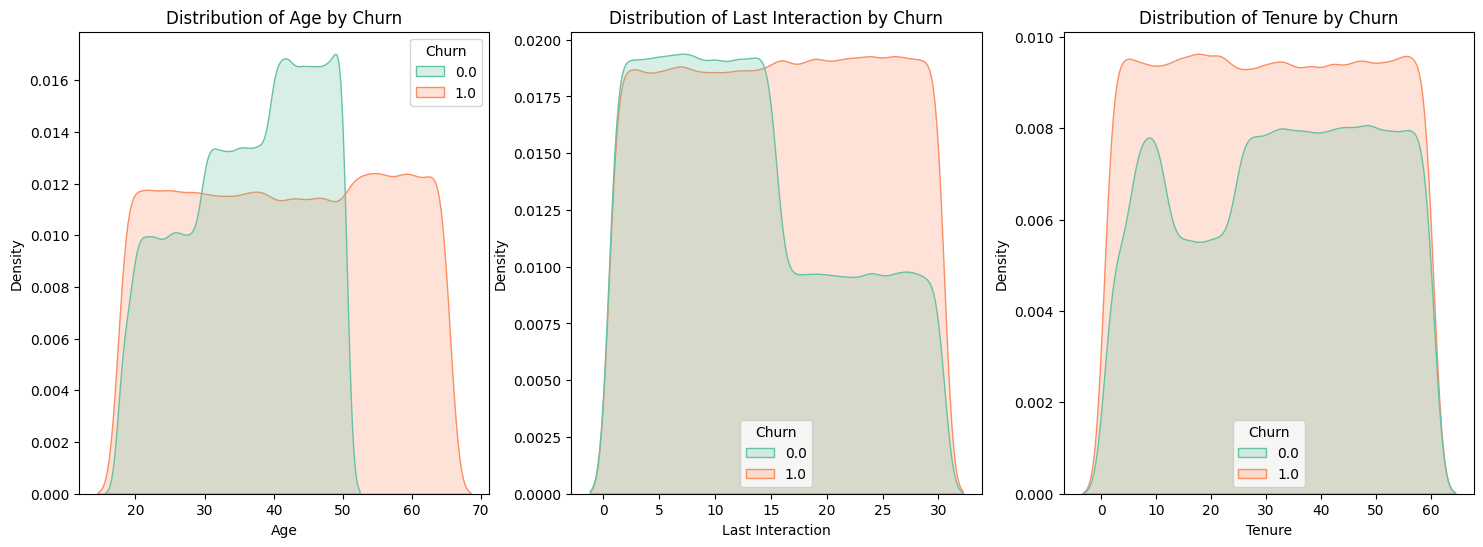

In [97]:
fg, ax = plt.subplots(1, 3, figsize=(18, 6))
for i, column in enumerate(["Age", "Last Interaction", "Tenure"]):
    sns.kdeplot(data=untransformed_data, x=column, hue="Churn", ax=ax[i], fill=True, palette='Set2')
    ax[i].set_title(f'Distribution of {column} by Churn', fontsize=12)

## **KNN Algorithm - implementation**

In [61]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt


In this section, we will build and evaluate our K-Nearest Neighbors (KNN) model. We start by importing all the necessary classes and functions from the `scikit-learn` library.

In [62]:
cols_X = [col for col in data.columns if col not in [
    'Churn', 'CustomerID']]

X = data[cols_X]
y = data['Churn']

We separate our data into features (X) and the target variable (y). `X` contains all columns except for 'Churn' and 'CustomerID'. `y` contains only the 'Churn' column, which is what we want to predict.

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

The dataset is split into a training set and a testing set. The model will learn from the training set, and then we will evaluate its performance on the unseen testing set. We use a 75/25 split. `stratify=y` ensures that the proportion of churned and not-churned customers is the same in both the training and testing sets, which is important for imbalanced datasets.

In [64]:
scaler = MinMaxScaler(clip=True)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The KNN algorithm is sensitive to the scale of the features because it uses distance calculations. Features with larger ranges can dominate the distance metric. To prevent this, we use `MinMaxScaler` to scale all features to a range between 0 and 1. We `fit_transform` on the training data to learn the scaling parameters and then only `transform` the test data using the same parameters. `clip=True` handles potential outliers in the test set that are outside the training set's range.

In [65]:
param_grid = {"n_neighbors": range(1, 16, 1)}
knn = KNeighborsClassifier(algorithm='auto')
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)
results_df = pd.DataFrame(grid_search.cv_results_)

Finding the best value for 'k' (the number of neighbors) is crucial for the KNN model. We use `GridSearchCV` to automate this process. It will test all values for `n_neighbors` from 1 to 15.
- `cv=5` means it will use 5-fold cross-validation. The training data is split into 5 parts; the model is trained on 4 and tested on 1, and this is repeated 5 times.
- `scoring="f1"` tells the grid search to choose the best 'k' based on the F1-score, which is a good metric for imbalanced classification problems as it balances precision and recall.

### Results

In [66]:
cols_to_show = [
    'param_n_neighbors',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]
clean_results = results_df[cols_to_show]
clean_results.sort_values(by='rank_test_score', ascending=True, inplace=True)
clean_results

,param_n_neighbors,mean_test_score,std_test_score,rank_test_score
2,3,0.962478,0.000675,1
4,5,0.960769,0.000859,2
0,1,0.959694,0.000290,3
6,7,0.959198,0.000798,4
8,9,0.957954,0.000651,5
10,11,0.956581,0.000807,6
12,13,0.955408,0.000720,7
14,15,0.954359,0.000730,8
3,4,0.954084,0.000995,9
5,6,0.954066,0.000800,10


We display the results from the grid search, sorted by their rank. Based on hyperparameter tuning, the KNN algorithm performed best with n_neighbors set to 3.

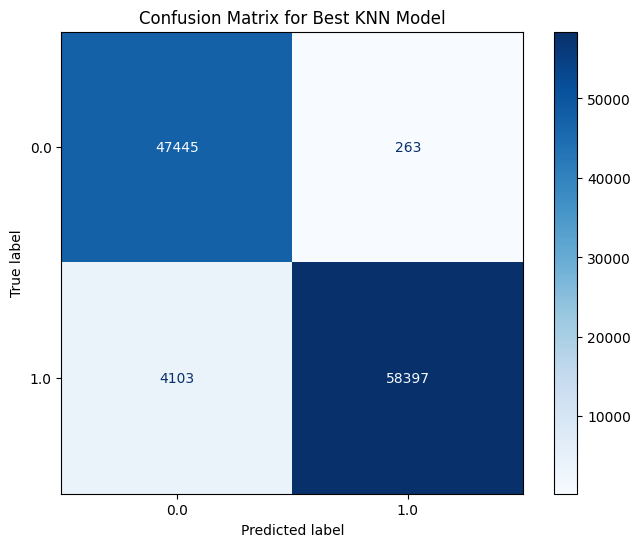

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = grid_search.best_estimator_

# Wyświetlenie macierzy pomyłek
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Best KNN Model")
plt.show()


Finally, we evaluate the best model on our test set. The confusion matrix gives us a detailed look at the model's performance.
- **False Positives (FP)**: Incorrectly predicted churn. (False alarm)
- **False Negatives (FN)**: Incorrectly predicted no churn. (Missed alarm)
This helps us understand what kind of errors our model is making.

In [ ]:
FP = 263
FN = 4103
TN = 47445
TP = 58397

FPR = FP / (FP + TN)
FPR = round(FPR, 4)
print(f"False Positive Rate (FPR): {FPR}")

FNR = FN / (FN + TP)
FNR = round(FNR, 4)
print(f"False Negative Rate (FNR): {FNR}")


False Positive Rate (FPR): 0.0055
False Negative Rate (FNR): 0.0656


The model has an exceptionally low "False Alarm" rate. Only 0.55% of loyal customers were incorrectly flagged as likely to churn.

The model missed approximately 6.57% of actual churners. These are customers who left without being detected by the alarm system.